# Predictive Maintenance and Maintenance Optimization

## Project Overview

This project aims to predict machine failures using machine learning techniques and optimize maintenance decisions based on predicted failure risks.

The project combines predictive analytics and optimization to support proactive maintenance planning, reduce equipment downtime, and improve maintenance resource allocation.

In [6]:
import pandas as pd

df = pd.read_csv("../data/raw/ai4i2020.csv")


In [7]:
df.info()
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

(10000, 14)

In [5]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [10]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [11]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

**Observation:**

The dataset contains 9,661 normal operating observations and 339 machine failure observations.

**Interpretation:**

Machine failures account for approximately 3.39% of all observations, indicating a highly imbalanced classification problem. Special attention will be required during model evaluation because accuracy alone may provide misleading results.

In [12]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


**Observation:**

The dataset contains realistic operating ranges for temperature, rotational speed, torque, and tool wear. Machine failures occur in only 3.39% of observations, confirming a highly imbalanced classification problem.

**Interpretation:**

Several variables, particularly tool wear, rotational speed, and torque, exhibit substantial variation and may play an important role in predicting machine failures. Further exploratory analysis is required to determine how these variables differ between normal and failed machine states.

## Machine Failure Distribution

In [13]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

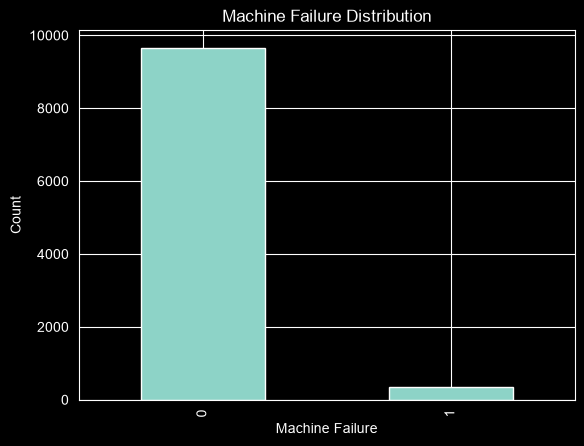

In [17]:
import matplotlib.pyplot as plt

df["Machine failure"].value_counts().plot(kind="bar")

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Count")
plt.savefig("../outputs/figures/01_failure_distribution.png", dpi=300)

plt.show()

**Observation:**

The dataset is highly imbalanced, with 96.61% normal operating observations and only 3.39% machine failure observations.

**Interpretation:**

Class imbalance is a common characteristic of predictive maintenance datasets because machine failures are relatively rare events. As a result, model evaluation should focus on metrics such as precision, recall, F1-score, and ROC-AUC rather than relying solely on accuracy.

## Feature Analysis

In [15]:
df.groupby("Machine failure")["Tool wear [min]"].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,106.693717,62.945790,0.0,52.0,107.0,160.0,246.0
1,339.0,143.781711,72.759876,0.0,84.5,165.0,207.5,253.0


**Observation:**

Machines that experienced failure have an average tool wear of 143.78 minutes, compared to 106.69 minutes for machines operating normally.

**Interpretation:**

Failed machines exhibit substantially higher tool wear, suggesting that accumulated wear contributes to increased failure risk. Tool wear is expected to be an important predictor in the machine learning models.

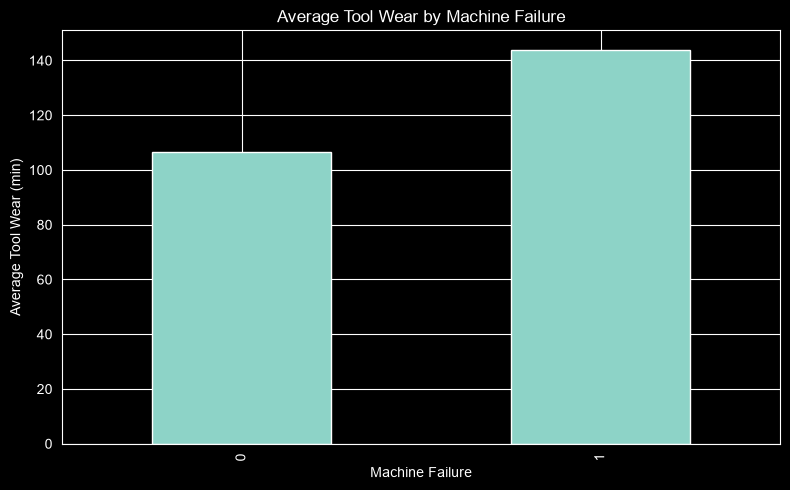

In [18]:
import matplotlib.pyplot as plt

tool_wear_failure = df.groupby("Machine failure")["Tool wear [min]"].mean()

plt.figure(figsize=(8,5))
tool_wear_failure.plot(kind="bar")

plt.title("Average Tool Wear by Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Average Tool Wear (min)")

plt.tight_layout()
plt.savefig("../outputs/figures/02_tool_wear_vs_failure.png", dpi=300)

plt.show()

**Observation:**

Machines that failed have an average tool wear of 143.78 minutes, compared to 106.69 minutes for machines operating normally.

**Interpretation:**

The visualization confirms that failed machines tend to exhibit substantially higher tool wear. This suggests that accumulated wear is an important contributor to machine failure and is likely to be one of the most influential features in the predictive maintenance models.

In [19]:
df.groupby("Machine failure")["Torque [Nm]"].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,39.629655,9.472080,12.6,33.10,39.9,46.3,70.0
1,339.0,50.168142,16.374498,3.8,45.95,53.7,61.2,76.6


**Observation:**

Failed machines have an average torque of 50.17 Nm compared to 39.63 Nm for normal machines.

**Interpretation:**

Machines operating under higher mechanical loads are more likely to fail. The substantial increase in average torque among failed machines suggests that mechanical stress is an important contributor to machine failure and may serve as a valuable predictor in the machine learning models.

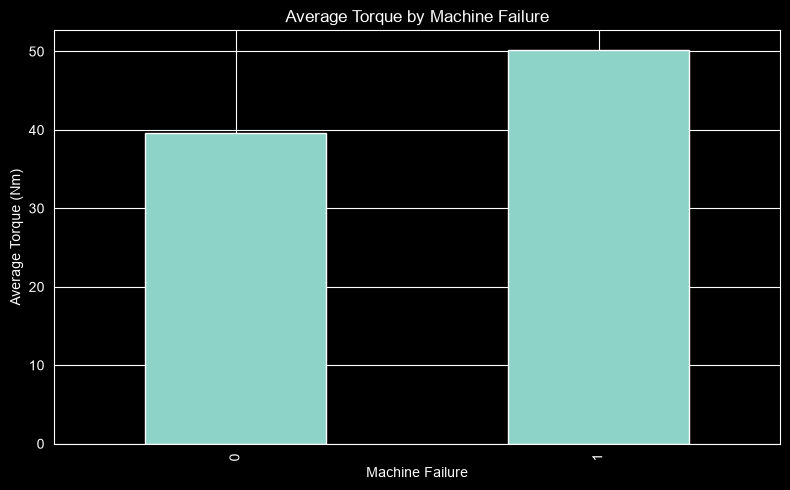

In [20]:
torque_failure = df.groupby("Machine failure")["Torque [Nm]"].mean()

plt.figure(figsize=(8,5))
torque_failure.plot(kind="bar")

plt.title("Average Torque by Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Average Torque (Nm)")

plt.tight_layout()
plt.savefig("../outputs/figures/03_torque_vs_failure.png", dpi=300)

plt.show()

**Observation:**

Failed machines exhibit an average torque of 50.17 Nm, compared to 39.63 Nm for normal machines.

**Interpretation:**

The chart demonstrates that machine failures are associated with higher mechanical loads. Increased torque places greater stress on machine components and appears to contribute to a higher probability of failure.

In [21]:
df.groupby("Machine failure")["Rotational speed [rpm]"].describe()

,count,mean,std,min,25%,50%,75%,max
Machine failure,,,,,,,,
0,9661.0,1540.260014,167.394734,1168.0,1429.0,1507.0,1615.0,2695.0
1,339.0,1496.486726,384.943547,1181.0,1326.5,1365.0,1421.5,2886.0


**Observation:**

Failed machines have an average rotational speed of 1496.49 rpm compared to 1540.26 rpm for normal machines. The failure group also exhibits substantially greater variability in rotational speed.

**Interpretation:**

Unlike tool wear and torque, rotational speed does not appear to have a simple linear relationship with machine failure. The large variability among failed machines suggests that failures may occur under both unusually low and unusually high operating speeds. Further visualization is required to better understand this relationship.

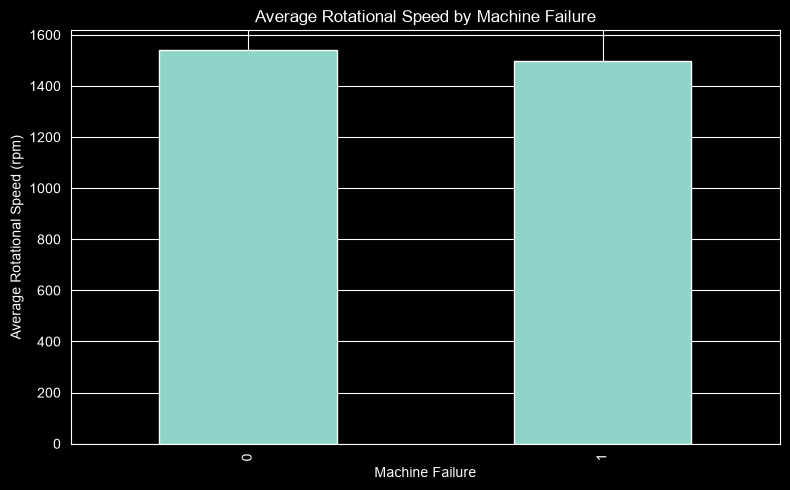

In [22]:
rpm_failure = df.groupby("Machine failure")["Rotational speed [rpm]"].mean()

plt.figure(figsize=(8,5))
rpm_failure.plot(kind="bar")

plt.title("Average Rotational Speed by Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Average Rotational Speed (rpm)")

plt.tight_layout()
plt.savefig("../outputs/figures/04_rpm_vs_failure.png", dpi=300)

plt.show()

**Observation:**

Normal machines operate at an average rotational speed of 1540 rpm, while failed machines operate at an average speed of 1496 rpm. The difference between the groups is relatively small compared to the differences observed for tool wear and torque.

**Interpretation:**

Rotational speed appears to have a weaker direct relationship with machine failure. Nevertheless, the greater variability among failed machines suggests that rotational speed may still provide predictive value when combined with other operational variables.

In [23]:
pd.crosstab(
    df["Type"],
    df["Machine failure"],
    margins=True
)

Machine failure,0,1,All
Type,,,
H,982,21,1003
L,5765,235,6000
M,2914,83,2997
All,9661,339,10000


In [24]:
pd.crosstab(
    df["Type"],
    df["Machine failure"],
    normalize="index"
) * 100

Machine failure,0,1
Type,,
H,97.906281,2.093719
L,96.083333,3.916667
M,97.230564,2.769436


**Observation:**

Failure rates differ across machine types. Low-quality machines (L) exhibit the highest failure rate at 3.92%, while high-quality machines (H) exhibit the lowest failure rate at 2.09%.

**Interpretation:**

Machine quality appears to influence reliability. Lower-quality machines fail more frequently than higher-quality machines, suggesting that machine type contains useful predictive information and should be retained in the modeling process.

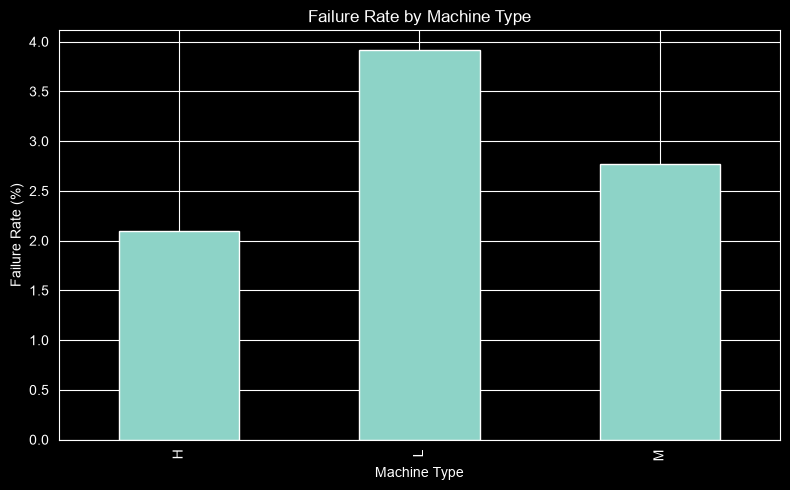

In [25]:
failure_rate = (
    pd.crosstab(
        df["Type"],
        df["Machine failure"],
        normalize="index"
    ) * 100
)[1]

plt.figure(figsize=(8,5))
failure_rate.plot(kind="bar")

plt.title("Failure Rate by Machine Type")
plt.xlabel("Machine Type")
plt.ylabel("Failure Rate (%)")

plt.tight_layout()
plt.savefig("../outputs/figures/05_failure_rate_by_machine_type.png", dpi=300)

plt.show()

**Observation:**

Low-quality machines exhibit the highest failure rate (3.92%), followed by medium-quality machines (2.77%) and high-quality machines (2.09%).

**Interpretation:**

The figure demonstrates a clear relationship between machine quality and reliability. Lower-quality machines are considerably more likely to fail than higher-quality machines, indicating that machine type provides valuable information for failure prediction.